In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import lorentzian, g, fermi_dirac
from scripts.utils import is_hermitian


In [3]:
class Lattice:
    def __init__(self, X, Y=None,
                 pbc_x=False, pbc_y=True):
        self.X = X
        Y = X if Y is None else Y
        self.Y = Y
        self.pbc_x = pbc_x
        self.pbc_y = pbc_y
        self.num_sites = X * Y

        edges_x = []
        edges_y = []
        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flat index for (x,y)

                # right neighbor (x+1, y)
                if x < X - 1:
                    edges_x.append((i, i + 1))
                elif pbc_x and X > 2:
                    edges_x.append((i, y * X))

                # down neighbor (x, y+1)
                if y < Y - 1:
                    edges_y.append((i, (y + 1) * X + x))
                elif pbc_y and Y > 2:
                    edges_y.append((i, x))
        self.edges_y = edges_y
        self.edges_x = edges_x

    def get_coords(self, i):
        y = i // self.X
        x = i % self.X
        return np.asarray([x, y], dtype=int)

    def get_disp(self, i, j):
        ri = self.get_coords(i)  # [xi, yi]
        rj = self.get_coords(j)  # [xj, yj]
        dr = np.subtract(rj, ri)  # [dx, dy]

        Lx, Ly = self.X, self.Y
        if self.pbc_x:
            if dr[0] > Lx // 2:
                dr[0] -= Lx
            elif dr[0] < -Lx // 2:
                dr[0] += Lx

        if self.pbc_y:
            if dr[1] > Ly // 2:
                dr[1] -= Ly
            elif dr[1] < -Ly // 2:
                dr[1] += Ly

        return dr

    def get_dir(self, i, j):
        dr = self.get_disp(i, j)
        if dr[0] == 1 and dr[1] == 0:
            return "+x"
        elif dr[0] == -1 and dr[1] == 0:
            return "-x"
        elif dr[0] == 0 and dr[1] == 1:
            return "+y"
        elif dr[0] == 0 and dr[1] == -1:
            return "-y"

    def get_edge_and_bulk_indices(X, Y, edge_width=1):
        edge_indices = []
        bulk_indices = []

        for y in range(Y):
            for x in range(X):
                i = y * X + x  # flattened index

                if (x < edge_width or x >= X - edge_width or
                        y < edge_width or y >= Y - edge_width):
                    edge_indices.append(i)
                else:
                    bulk_indices.append(i)

        return edge_indices, bulk_indices

    def plot(self, highlight=None, path=None):
        fig, ax = plt.subplots(figsize=(6, 6))
        coords = {}

        for y in range(self.Y):
            for x in range(self.X):
                i = y * self.X + x
                coords[i] = (x, -y)

        for i, j in self.edges_x + self.edges_y:
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            ax.plot([x1, x2], [y1, y2], 'k-', lw=1)

        for i, (xx, yy) in coords.items():
            ax.plot(xx, yy, 'ro')
            ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                    color="white", bbox=dict(facecolor="black",
                                             edgecolor="none",
                                             boxstyle="circle,pad=0.25"))
            if highlight is not None and i in highlight:
                ax.plot(xx, yy, 'ro')
                ax.text(xx, yy, str(i), fontsize=10, ha='center', va='center',
                        color="black", bbox=dict(facecolor="red",
                                                 edgecolor="none",
                                                 boxstyle="circle,pad=0.25"))

        ax.set_aspect("equal")
        ax.axis("off")
        if path is not None:
            plt.savefig(path, bbox_inches='tight')
        plt.show()


class Hamiltonian:
    def __init__(self, t, mu, lattice,
                 U=None, V=None, V_prime=None,
                 F0_init=0, F_init=np.zeros(4),
                 Fuu_init=np.zeros(4),
                 Fdd_init=np.zeros(4)):
        '''
        Sets the hamiltonian parameters and initial conditions
        '''
        self.t = t
        self.mu = mu
        self.lattice = lattice
        Nx = lattice.X
        self.dim = 4 * Nx

        if U is None:
            U = np.zeros(Nx)
        if V is None:
            V = np.zeros(Nx)
        if V_prime is None:
            V_prime = np.zeros(Nx)
        self.U = U
        self.V = V
        self.V_prime = V_prime

        self.F0 = np.zeros(Nx, dtype=np.complex128)
        self.F0[np.where(U != 0)] = F0_init
        self.F_xplus = np.zeros(Nx-1, dtype=np.complex128)
        self.F_xplus[np.where(V[:-1] != 0)] = F_init[0]
        self.F_xmin = np.zeros(Nx-1, dtype=np.complex128)
        self.F_xmin[np.where(V[:-1] != 0)] = F_init[1]
        self.F_yplus = np.zeros(Nx, dtype=np.complex128)
        self.F_yplus[np.where(V != 0)] = F_init[2]
        self.F_ymin = np.zeros(Nx, dtype=np.complex128)
        self.F_ymin[np.where(V != 0)] = F_init[3]

        self.Fuu_xplus = np.zeros(Nx-1, dtype=np.complex128)
        self.Fuu_xplus[np.where(V_prime[:-1] != 0)] = Fuu_init[0]
        self.Fuu_xmin = np.zeros(Nx-1, dtype=np.complex128)
        self.Fuu_xmin[np.where(V_prime[:-1] != 0)] = Fuu_init[1]
        self.Fuu_yplus = np.zeros(Nx, dtype=np.complex128)
        self.Fuu_yplus[np.where(V_prime != 0)] = Fuu_init[2]
        self.Fuu_ymin = np.zeros(Nx, dtype=np.complex128)
        self.Fuu_ymin[np.where(V_prime != 0)] = Fuu_init[3]

        self.Fdd_xplus = np.zeros(Nx-1, dtype=np.complex128)
        self.Fdd_xplus[np.where(V_prime[:-1] != 0)] = Fdd_init[0]
        self.Fdd_xmin = np.zeros(Nx-1, dtype=np.complex128)
        self.Fdd_xmin[np.where(V_prime[:-1] != 0)] = Fdd_init[1]
        self.Fdd_yplus = np.zeros(Nx, dtype=np.complex128)
        self.Fdd_yplus[np.where(V_prime != 0)] = Fdd_init[2]
        self.Fdd_ymin = np.zeros(Nx, dtype=np.complex128)
        self.Fdd_ymin[np.where(V_prime != 0)] = Fdd_init[3]

        # self.set_kindep(gap0, gap1, gap2, gap1_uu, gap2_uu, gap1_dd, gap2_dd)

    def get_dim(self):
        return self.dim

    def set_kindep(self, gap0, gap1, gap2, gap1_uu, gap2_uu, gap1_dd, gap2_dd):

        self.matrix = np.zeros((self.dim, self.dim), dtype=np.complex128)
        t = self.t

        # set in diagonal elements (mu + 2cos(0))
        for i in range(self.lattice.X):
            diag = - self.mu[i]  # - 2.0 * t *cos(0)
            sl = slice(4 * i, 4 * i + 4)
            self.matrix[sl, sl] += np.diag(np.array(
                [diag, diag, -diag, -diag]
            ))
            # set in BCS gap
            block = np.zeros((4, 4), dtype=np.complex128)
            block[0, 3] = gap0[i]
            block[1, 2] = -gap0[i]
            block[2:, :2] = block[:2, 2:].conj().T
            self.matrix[sl, sl] += block

        # set in hopping block in x direction
        for i in range(self.lattice.X-1):
            sli = slice(4 * i, 4 * i + 4)
            slj = slice(4 * (i + 1), 4 * (i + 1) + 4)
            self.matrix[sli, slj] += np.diag(np.array(
                [-t, -t, t, t]
            ))
            self.matrix[slj, sli] += np.diag(np.array(
                [-t, -t, t, t]
            ))

            # # x+
            upper = np.zeros((4, 4), dtype=np.complex128)
            upper[0, 2] = gap2_uu[i]
            upper[0, 3] = gap2[i]
            upper[1, 2] = -gap1[i]
            upper[1, 3] = gap2_dd[i]

            # # x-
            lower = np.zeros((4, 4), dtype=np.complex128)
            lower[0, 2] = gap1_uu[i]
            lower[0, 3] = gap1[i]
            lower[1, 2] = -gap2[i]
            lower[1, 3] = gap1_dd[i]

            lower[2:, :2] = upper[:2, 2:].T.conj()
            upper[2:, :2] = lower[:2, 2:].T.conj()

            self.matrix[sli, slj] += upper
            self.matrix[slj, sli] += lower

    def build_H_k0(self):
        H = np.zeros((self.dim, self.dim), dtype=np.complex128)

        gap1 = self.V * (self.F_yplus + self.F_ymin)
        gap2 = -self.V * (self.F_yplus + self.F_ymin)
        # gap1_uu = self.V_prime[1:] * self.Fuu_xmin
        # gap2_uu = self.V_prime[:-1] * self.Fuu_xplus
        # gap1_dd = self.V_prime[1:] * self.Fuu_xmin
        # gap2_dd = self.V_prime[:-1] * self.Fuu_xplus

        for i in range(self.lattice.X):
            H[g(i, 0), g(i, 0)] = -2 * self.t
            H[g(i, 1), g(i, 1)] = -2 * self.t
            H[g(i, 2), g(i, 2)] = 2 * self.t
            H[g(i, 3), g(i, 3)] = 2 * self.t

            H[g(i, 0), g(i, 3)] = gap1[i]
            H[g(i, 1), g(i, 2)] = gap2[i]
            H[g(i, 2), g(i, 1)] = np.conj(gap2[i])
            H[g(i, 3), g(i, 0)] = np.conj(gap1[i])
        return H

    def build_H_kindep(self):
        gap0 = self.U * self.F0
        gap1 = self.V[1:] * self.F_xmin
        gap2 = self.V[:-1] * self.F_xplus

        H = np.zeros((self.dim, self.dim), dtype=np.complex128)


        for i in range(self.lattice.X):
            H[g(i, 0), g(i, 0)] = -self.mu[i]
            H[g(i, 1), g(i, 1)] = -self.mu[i]
            H[g(i, 2), g(i, 2)] = self.mu[i]
            H[g(i, 3), g(i, 3)] = self.mu[i]

            H[g(i, 0), g(i, 3)] = gap0[i]
            H[g(i, 1), g(i, 2)] = -gap0[i]
            H[g(i, 2), g(i, 1)] = np.conj(-gap0[i])
            H[g(i, 3), g(i, 0)] = np.conj(gap0[i])


        for i in range(self.lattice.X - 1):
            for c, hop in enumerate([-self.t, -self.t, self.t, self.t]):
                H[g(i, c),   g(i + 1, c)] = hop
                H[g(i + 1, c), g(i, c)] = hop

            # upper
            H[g(i, 0), g(i+1, 3)] = gap2[i]
            H[g(i, 1), g(i+1, 2)] = -gap1[i]
            H[g(i, 2), g(i+1, 1)] = -np.conj(gap2[i])
            H[g(i, 3), g(i+1, 0)] = np.conj(gap1[i])

            # lower
            H[g(i+1, 0), g(i, 3)] = gap1[i]
            H[g(i+1, 1), g(i, 2)] = -gap2[i]
            H[g(i+1, 2), g(i, 1)] = -np.conj(gap1[i])
            H[g(i+1, 3), g(i, 0)] = np.conj(gap2[i])

        return H

    def build_H_k(self, k):
        H2 = np.zeros((self.dim, self.dim), dtype=np.complex128)

        epsilon = -2 * self.t * np.cos(k)
        ep = np.exp(1j * k)
        em = np.exp(-1j * k)

        # y-pairing with phase
        gap1 = self.V * (self.F_yplus * em + self.F_ymin * ep)
        gap2 = -self.V * (self.F_yplus * ep + self.F_ymin * em)

        for i in range(self.lattice.X):
            # dispersion
            H2[g(i, 0), g(i, 0)] = epsilon
            H2[g(i, 1), g(i, 1)] = epsilon
            H2[g(i, 2), g(i, 2)] = -epsilon
            H2[g(i, 3), g(i, 3)] = -epsilon

            H2[g(i, 0), g(i, 3)] = gap1[i]
            H2[g(i, 1), g(i, 2)] = gap2[i]
            H2[g(i, 2), g(i, 1)] = np.conj(gap2[i])
            H2[g(i, 3), g(i, 0)] = np.conj(gap1[i])

        return H2

    def get_correlations(self):
        return (self.F0.copy(),
                self.F_xplus.copy(), self.F_xmin.copy(),
                self.F_yplus.copy(), self.F_ymin.copy(),
                self.Fuu_xplus, self.Fuu_xmin, self.Fuu_yplus, self.Fuu_ymin,
                self.Fdd_xplus, self.Fdd_xmin, self.Fdd_yplus, self.Fdd_ymin)

    def set_correlations(self, corr):
        self.F0 = corr[0].copy()

        self.F_xplus = corr[1].copy()
        self.F_xmin = corr[2].copy()
        self.F_yplus = corr[3].copy()
        self.F_ymin = corr[4].copy()

In [4]:
block = np.zeros((4,4), dtype=np.complex128)
gap0 = 0.1 + 0.2j
print(gap0)
print(np.conj(gap0))
print(np.conj((-gap0)))
print(-np.conj((gap0)))

block[0,3] = gap0
block[1,2] = -gap0
block[2,1] = np.conj(-gap0)
block[3,0] = np.conj(gap0)

print(block)


block[:2, 2:] = 1j * gap0 * s2
block[2:, :2] = (1j * gap0 * s2.T).conj()

print(block)

(0.1+0.2j)
(0.1-0.2j)
(-0.1+0.2j)
(-0.1+0.2j)
[[ 0. +0.j   0. +0.j   0. +0.j   0.1+0.2j]
 [ 0. +0.j   0. +0.j  -0.1-0.2j  0. +0.j ]
 [ 0. +0.j  -0.1+0.2j  0. +0.j   0. +0.j ]
 [ 0.1-0.2j  0. +0.j   0. +0.j   0. +0.j ]]
[[ 0. +0.j   0. +0.j  -0. +0.j   0.1+0.2j]
 [ 0. +0.j   0. +0.j  -0.1-0.2j -0. +0.j ]
 [-0. -0.j  -0.1+0.2j  0. +0.j   0. +0.j ]
 [ 0.1-0.2j -0. -0.j   0. +0.j   0. +0.j ]]


In [5]:
def bdg_sc(H: Hamiltonian, temperature=0,  # Hamiltonian
           atol=1e-6, rtol=1e-4, maxiter=100, verbose=False):

    Ny = H.lattice.Y
    Nx = H.lattice.X
    ky_list = np.linspace(PI / Ny, PI, Ny)

    F0 = H.F0.copy()
    Fx_plus = H.F_xplus.copy()
    Fx_min = H.F_xmin.copy()
    Fy_plus = H.F_yplus.copy()
    Fy_min = H.F_ymin.copy()

    for iteration in range(maxiter):

        H_kindep = H.build_H_kindep()
        H_k0 = H.build_H_k0()

        eigval0, eigvec0 = la.eigh(H_kindep + H_k0)

        u0 = eigvec0[0::4, :]
        v0 = eigvec0[1::4, :]
        w0 = eigvec0[2::4, :]
        x0 = eigvec0[3::4, :]

        Energies0 = np.tile(eigval0, (Nx, 1))
        f_E0 = fermi_dirac(Energies0, temperature)
        f0 = fermi_dirac(eigval0, temperature)
        pos_energy0 = Energies0 > 0

        F0_new = (np.einsum('nm,nm,m->n', u0, np.conj(x0), (1-f0)) +
                  np.einsum('nm,nm,m->n', v0, np.conj(w0), f0)) / Ny

        # Pair correlations (k=0), filtered to positive energies as in MATLAB
        Fx0_ux1 = u0[:-1, :] * np.conj(x0[1:, :]) * (1 - f_E0[:-1, :]) * pos_energy0[:-1, :]
        Fx0_ux2 = u0[1:, :] * np.conj(x0[:-1, :]) * (1 - f_E0[1:, :]) * pos_energy0[1:, :]
        Fx0_vw1 = v0[:-1, :] * np.conj(w0[1:, :]) * (f_E0[1:, :]) * pos_energy0[1:, :]
        Fx0_vw2 = v0[1:, :] * np.conj(w0[:-1, :]) * (f_E0[:-1, :]) * pos_energy0[:-1, :]

        Fy0_ux = u0 * np.conj(x0) * (1 - f_E0) * pos_energy0
        Fy0_vw = v0 * np.conj(w0) * (f_E0) * pos_energy0

        Fx_plus_new = np.sum(Fx0_ux1 + Fx0_vw2, axis=1) / Ny
        Fx_min_new = np.sum(Fx0_ux2 + Fx0_vw1, axis=1) / Ny
        K_y0 = np.sum(Fy0_ux + Fy0_vw, axis=1) / Ny
        Fy_plus_new = K_y0.copy()
        Fy_min_new = K_y0.copy()

        # Singlet / triplet symmetry parts (initialised with k=0)
        FS_x = np.sum(Fx0_ux1 + Fx0_ux2 + Fx0_vw1 + Fx0_vw2, axis=1).conj().T / (2.0 * Ny)
        FS_y = K_y0.copy()

        FT_x_plus = np.sum(Fx0_ux1 - Fx0_ux2 + Fx0_vw2 - Fx0_vw1, axis=1).conj().T / (2.0 * Ny)
        FT_x_min  = np.sum(Fx0_ux2 - Fx0_ux1 + Fx0_vw1 - Fx0_vw2, axis=1).conj().T / (2.0 * Ny)
        FT_y_plus = np.zeros(Nx, dtype=np.complex128)
        FT_y_min  = np.zeros(Nx, dtype=np.complex128)


        for ky in ky_list:
            H_k = H.build_H_k(ky)
            H2 = H_kindep + H_k

            eigval, eigvec = la.eigh(H2)

            u = eigvec[0::4, :]
            v = eigvec[1::4, :]
            w = eigvec[2::4, :]
            x = eigvec[3::4, :]

            Energies = np.tile(eigval, (Nx, 1))
            f_E = fermi_dirac(Energies, temperature)
            f = fermi_dirac(eigval, temperature)

            F0_new += (np.einsum('nm,nm,m->n', u, np.conj(x), (1-f)) +
                       np.einsum('nm,nm,m->n', v, np.conj(w), f)) / Ny

            Fx_ux1 = u[:-1, :] * np.conj(x[1:, :]) * (1 - f_E[:-1, :])
            Fx_ux2 = u[1:, :] * np.conj(x[:-1, :]) * (1 - f_E[1:, :])
            Fx_vw1 = v[:-1, :] * np.conj(w[1:, :]) * (f_E[1:, :])
            Fx_vw2 = v[1:, :] * np.conj(w[:-1, :]) * (f_E[:-1, :])

            Fy_ux = u * np.conj(x) * (1 - f_E)
            Fy_vw = v * np.conj(w) * (f_E)

            e = np.exp(1j * ky)
            em = np.exp(-1j * ky)

            Fx_plus_new += np.sum(Fx_ux1 + Fx_vw2, axis=1) / Ny
            Fx_min_new += np.sum(Fx_ux2 + Fx_vw1, axis=1) / Ny
            Fy_plus_new += np.sum(Fy_ux * e + Fy_vw * em, axis=1) / Ny
            Fy_min_new += np.sum(Fy_ux * em + Fy_vw * e,  axis=1) / Ny

            # Singlet component
            FS_x += np.sum(Fx_ux1 + Fx_ux2 + Fx_vw1 + Fx_vw2, axis=1) / (2.0 * Ny)
            FS_y += np.sum(Fy_ux + Fy_vw, axis=1) * np.cos(ky) / Ny

            # Triplet component
            FT_x_plus += np.sum(Fx_ux1 - Fx_ux2 + Fx_vw2 - Fx_vw1, axis=1) / (2.0 * Ny)
            FT_x_min  += np.sum(Fx_ux2 - Fx_ux1 + Fx_vw1 - Fx_vw2, axis=1) / (2.0 * Ny)

            FT_y_plus += 1j * np.sum(Fy_ux - Fy_vw, axis=1) * np.sin(ky) / Ny
            FT_y_min  -= 1j * np.sum(Fy_ux - Fy_vw, axis=1) * np.sin(ky) / Ny

        # Filtering out s, d, px, py (same algebra as MATLAB)
        F_swave = (np.r_[0, FS_x] + np.r_[FS_x, 0] + 2.0 * FS_y) / 4.0
        F_dwave = (np.r_[0, FS_x] + np.r_[FS_x, 0] - 2.0 * FS_y) / 4.0
        F_px = (np.r_[0, FT_x_plus] - np.r_[FT_x_min, 0]) / 2.0
        F_py = (FT_y_plus - FT_y_min) / 2.0

        # Convergence metrics
        absdiff0 = np.linalg.norm(F0_new - F0)
        absdiff1 = np.linalg.norm(Fx_plus_new - Fx_plus)
        absdiff2 = np.linalg.norm(Fx_min_new - Fx_min)
        absdiff3 = np.linalg.norm(Fy_plus_new - Fy_plus)
        absdiff4 = np.linalg.norm(Fy_min_new - Fy_min)

        # avoid divide-by-zero blow-ups
        eps = 1e-12
        reldiff0 = np.linalg.norm((F0_new - F0)/(F0 + eps))
        reldiff1 = np.linalg.norm((Fx_plus_new - Fx_plus)/(Fx_plus + eps))
        reldiff2 = np.linalg.norm((Fx_min_new - Fx_min)/(Fx_min + eps))
        reldiff3 = np.linalg.norm((Fy_plus_new - Fy_plus)/(Fy_plus + eps))
        reldiff4 = np.linalg.norm((Fy_min_new - Fy_min)/(Fy_min + eps))

        c1 = (absdiff0 < atol) and (absdiff1 < atol) and (absdiff2 < atol) and (absdiff3 < atol) and (absdiff4 < atol)
        c2 = (reldiff0 < rtol) and (reldiff1 < rtol) and (reldiff2 < rtol) and (reldiff3 < rtol) and (reldiff4 < rtol)
        
        corr = [F0, Fx_plus, Fx_min, Fy_plus, Fy_min]
        corr_new = [F0_new, Fx_plus_new, Fx_min_new, Fy_plus_new, Fy_min_new]

        if verbose:
            abs_diff = [absdiff0, absdiff1, absdiff2, absdiff3, absdiff4]
            rel_diff = [reldiff0, reldiff1, reldiff2, reldiff3, reldiff4]

            print('============================================')
            print(f"Iteration {iteration + 1}:")
            correlation_strings = [
            "F0", "F_xplus", "F_xmin", "F_yplus", "F_ymin"]
            for idx in range(len(abs_diff)):
                print(f"{correlation_strings[idx]}:")
                print(f"Absolute error: {abs_diff[idx]}")
                print(f"Relative error: {rel_diff[idx]}")
                print(f"Average old: {np.mean(corr[idx])}")
                print(f"Average: {np.mean(corr_new[idx])}")

        F0 = F0_new.copy()
        Fx_plus = Fx_plus_new.copy()
        Fx_min = Fx_min_new.copy()
        Fy_plus = Fy_plus_new.copy()
        Fy_min = Fy_min_new.copy()

        H.set_correlations(corr_new)

        if c1 and c2:
            print(f"Converged after {iteration+1} iterations")
            break
    print(f"WARNING: Failed to converge after {iteration+1}iterations")
    return F_swave, F_dwave, F_px, F_py

In [35]:
X, Y = 10,50
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-12
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V, F0_init=0.0,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [36]:
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_k(PI/3)))

True
True
True


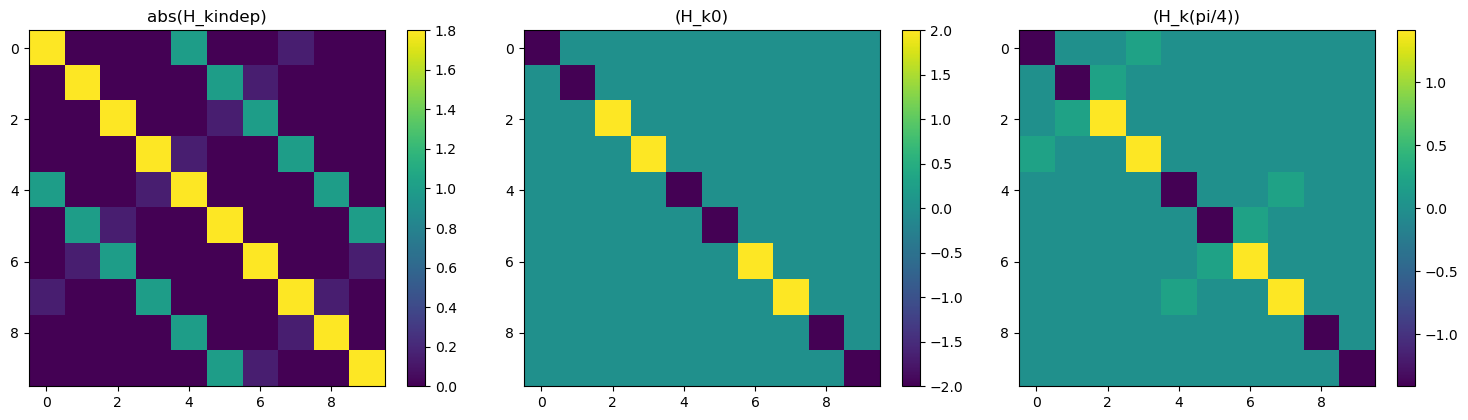

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

im0 = axs[0].imshow(np.abs(H.build_H_kindep())[0:10, 0:10])
axs[0].set_title("abs(H_kindep)")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(np.real(H.build_H_k0())[0:10, 0:10])
axs[1].set_title("(H_k0)")
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(np.real(H.build_H_k(PI/4))[0:10, 0:10])
axs[2].set_title("(H_k(pi/4))")
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()


In [38]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, maxiter=500, verbose=True, temperature=T)

d:\X-files\Master Thesis\master-thesis-codebase\scripts\utils.py:60: RuntimeWarning: overflow encountered in exp
  return 1.0 / (np.exp(energy / T) + 1.0)


Iteration 1:
F0:
Absolute error: 5.751820393618809e-16
Relative error: 0.0005751820393618809
Average old: 0j
Average: (-2.0953862932694263e-17+0j)
F_xplus:
Absolute error: 0.0384862639215058
Relative error: 0.3848626392112094
Average old: (0.09999999999999999+0j)
Average: (0.10372367883709555+0j)
F_xmin:
Absolute error: 0.0384862639215056
Relative error: 0.3848626392189046
Average old: (-0.09999999999999999+0j)
Average: (-0.10372367883709525+0j)
F_yplus:
Absolute error: 0.11155654683225166
Relative error: 1.1155654683225167
Average old: 0.1j
Average: (5.578614555978163e-17+0.13463179065817274j)
F_ymin:
Absolute error: 0.11155654683225166
Relative error: 1.1155654683225167
Average old: -0.1j
Average: (5.578614555978163e-17-0.13463179065817274j)
Iteration 2:
F0:
Absolute error: 3.543057311881358e-16
Relative error: 0.0003542867472990408
Average old: (-2.0953862932694263e-17+0j)
Average: (-1.1431810046050214e-16+0j)
F_xplus:
Absolute error: 0.022141227534726807
Relative error: 0.210124980

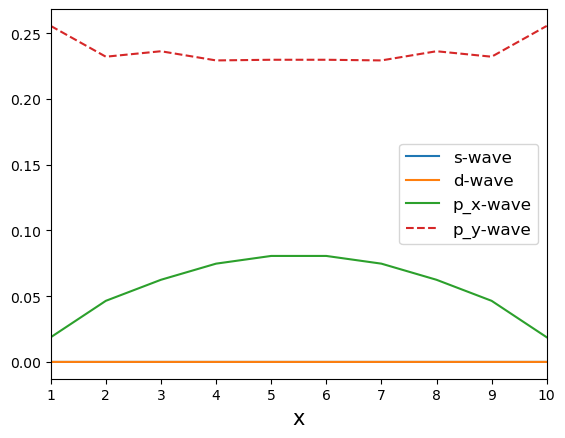

In [39]:
x = np.arange(1, 10 + 1)

plt.figure()
plt.plot(x, np.real(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.imag(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, 10)
plt.legend(fontsize=12, loc="best")
plt.show()

Iteration 1:
F0:
Absolute error: 0.0009145358808744515
Relative error: 914535880.8744514
Average old: 0j
Average: (3.943333877494282e-05+0j)
F_xplus:
Absolute error: 0.04832421888268223
Relative error: 12290417525.703068
Average old: (0.005084745762711865+0j)
Average: (0.009974111645845805+0j)
F_xmin:
Absolute error: 0.04892950012272362
Relative error: 12594121539.048744
Average old: (-0.005084745762711865+0j)
Average: (-0.01009898353604226+0j)
F_yplus:
Absolute error: 0.08440107413445933
Relative error: 14859979016.758314
Average old: 0.0051666666666666675j
Average: (1.6234787282123693e-05+0.013964582996841626j)
F_ymin:
Absolute error: 0.08440107413445933
Relative error: 14859979016.758314
Average old: -0.0051666666666666675j
Average: (1.6234787282123693e-05-0.013964582996841626j)
Iteration 2:
F0:
Absolute error: 0.001067605695070006
Relative error: 23.811300574351915
Average old: (3.943333877494282e-05+0j)
Average: (8.223314026810372e-05+0j)
F_xplus:
Absolute error: 0.086617936353393

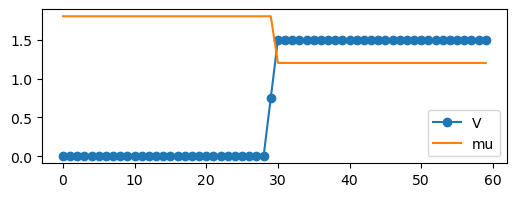

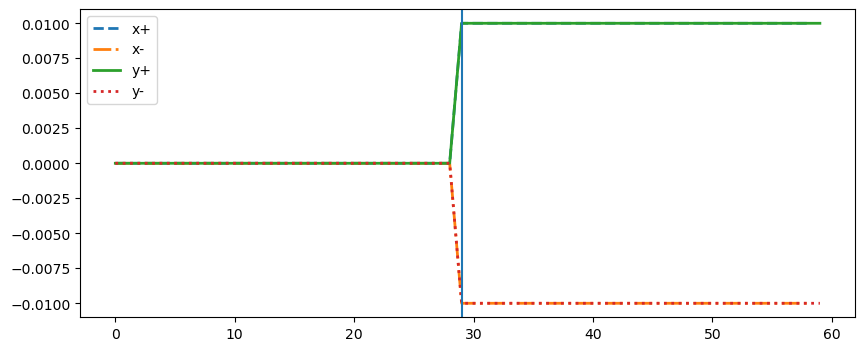

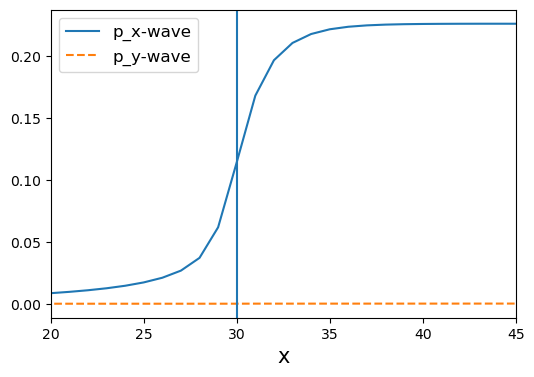

In [6]:
widthN = 30
widthP = 30

X, Y = widthN+widthP, 50
lattice = Lattice(X, Y)
t = 1
T = 0.02
muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[widthN:] = muN
mu[:widthN] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0
U[widthN-1] = U[widthN-1]/2
U = None

V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 
V[widthN-1] = V[widthN]/2
# V = None

V_prime = V0 * np.ones(lattice.X)
V_prime[:widthN] = 0
V_prime[widthN-1] = V_prime[widthN]/2
V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, label='mu')
plt.legend()
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V, F_init=[0.01, -0.01, 0.01j, -0.01j])

plt.figure(figsize=(10,4))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthN-1)
T = 0.01
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=1000, verbose=True, temperature=T)

F_yplus = H.F_yplus
F_ymin = H.F_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.F_xplus
F_xmin[1:]  = H.F_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2
x = np.arange(1, 60 + 1)

fig, axs = plt.subplots(1, 1, figsize=(6, 4))

# axs.plot(x, np.real(F_swave), label="s-wave")
# axs.plot(x, np.real(F_dwave), label="d-wave")
axs.plot(x, np.real(F_px), label="p_x-wave")
axs.plot(x, np.imag(F_py), "--", label="p_y-wave")
axs.axvline(30)
axs.set_xlabel("x", fontsize=15)
axs.set_xlim(20, 45)
axs.legend(fontsize=12, loc="best")
plt.show()

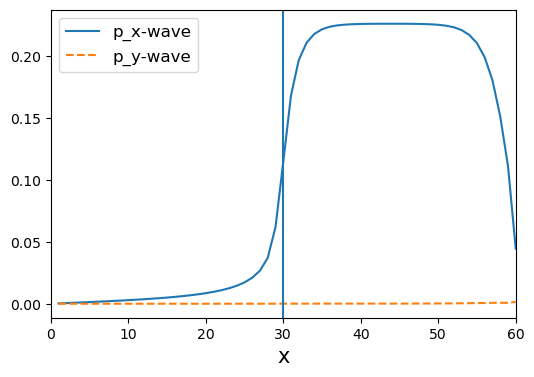

In [7]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

# axs.plot(x, np.real(F_swave), label="s-wave")
# axs.plot(x, np.real(F_dwave), label="d-wave")
axs.plot(x, np.real(F_px), label="p_x-wave")
axs.plot(x, np.imag(F_py), "--", label="p_y-wave")
axs.axvline(30)
axs.set_xlabel("x", fontsize=15)
axs.set_xlim(0, 60)
axs.legend(fontsize=12, loc="best")
plt.show()